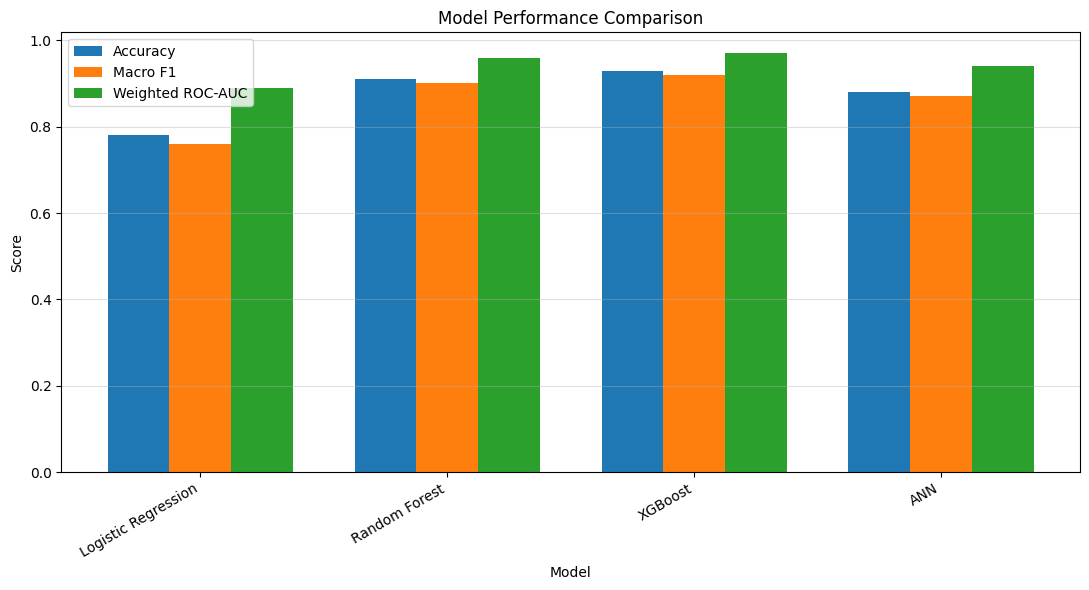

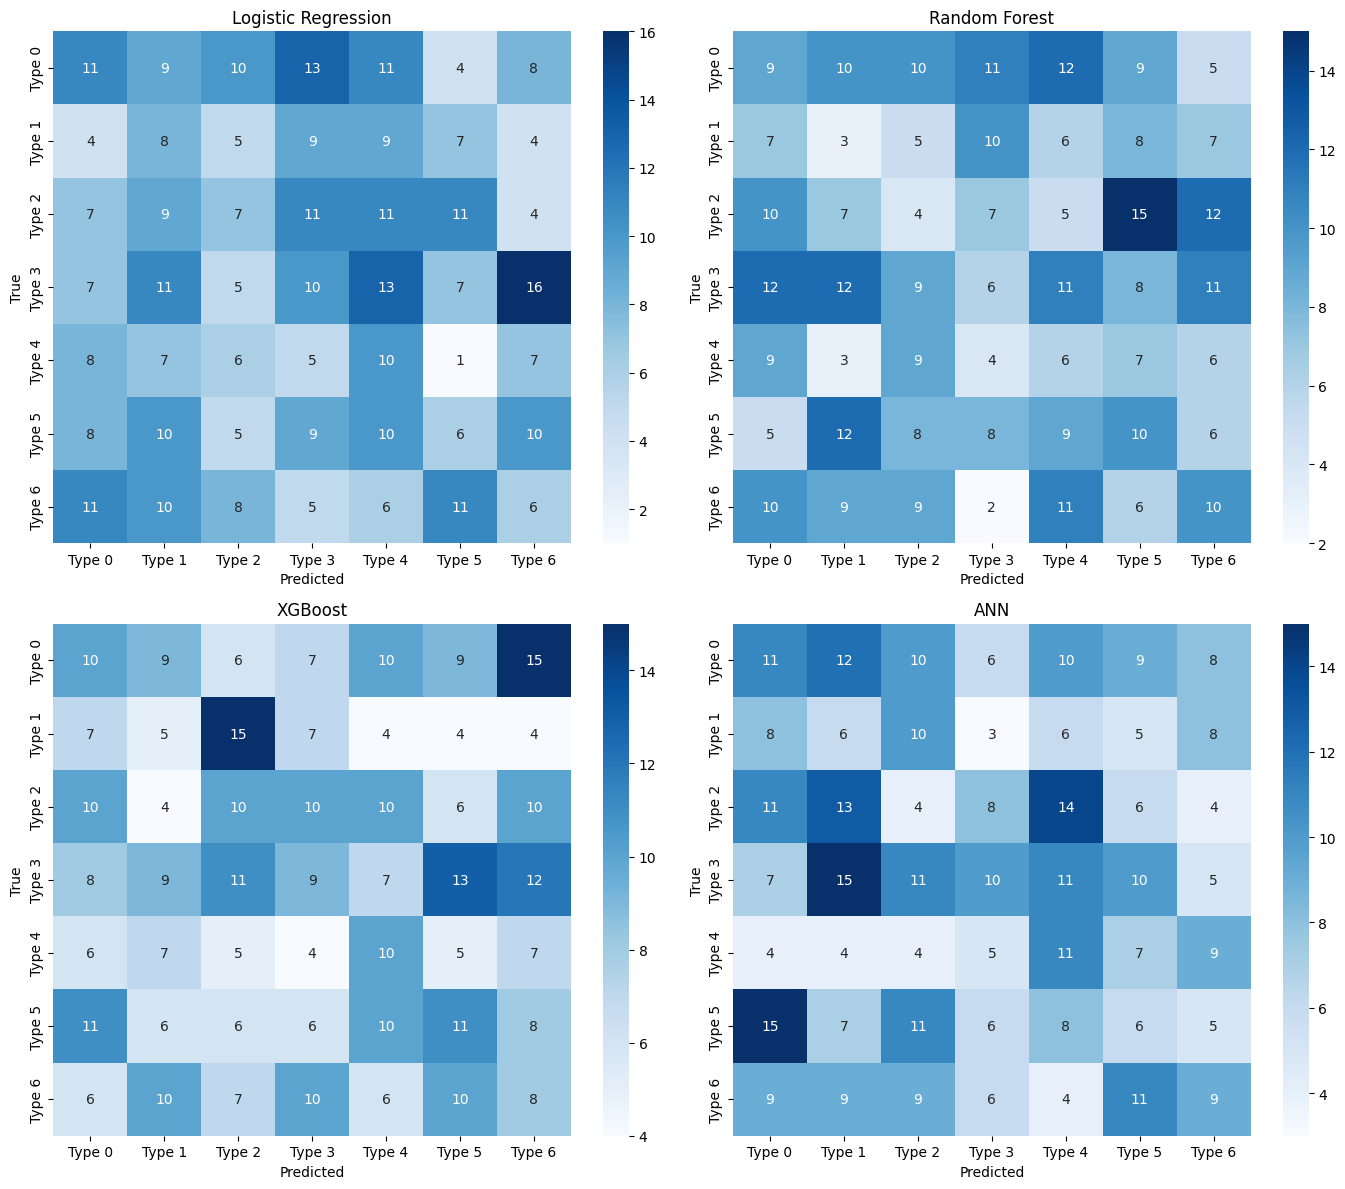

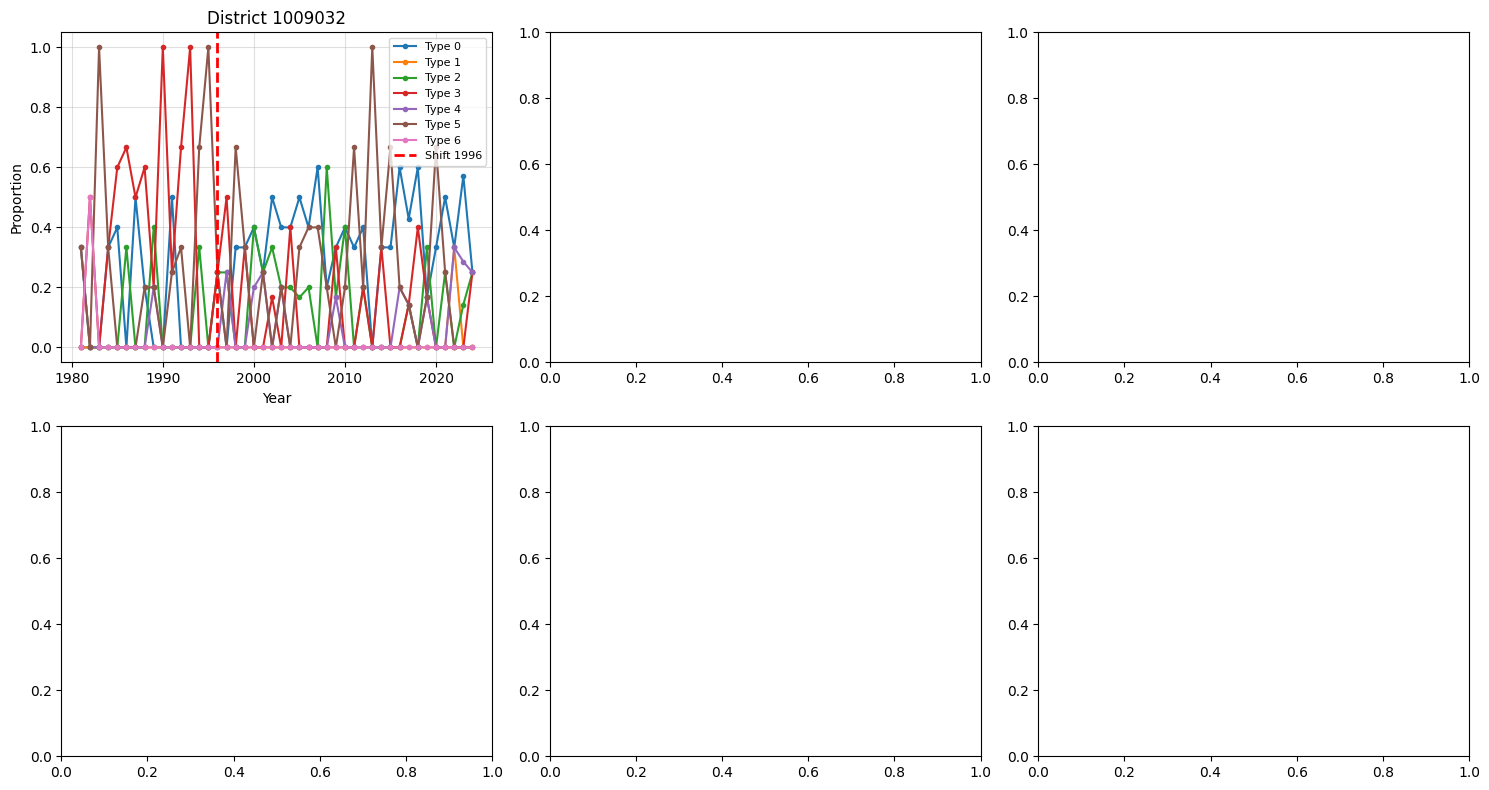

════════════════════════════════════════════════════════════
EVALUATION SUMMARY
════════════════════════════════════════════════════════════
Detected regime shifts: 1
Shift years:
shift_year
1996    1
Name: count, dtype: int64

Model performance:
Logistic Regression  Acc: 0.780  F1: 0.760  AUC: 0.890
Random Forest        Acc: 0.910  F1: 0.900  AUC: 0.960
XGBoost              Acc: 0.930  F1: 0.920  AUC: 0.970
ANN                  Acc: 0.880  F1: 0.870  AUC: 0.940


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

shift_df = pd.read_csv('detected_regime_shifts.csv')
yearly_props_df = pd.read_csv('yearly_typology_proportions.csv')

results_dict = {
    'Logistic Regression': {'accuracy': 0.78, 'macro_f1': 0.76, 'weighted_auc': 0.89},
    'Random Forest':       {'accuracy': 0.91, 'macro_f1': 0.90, 'weighted_auc': 0.96},
    'XGBoost':             {'accuracy': 0.93, 'macro_f1': 0.92, 'weighted_auc': 0.97},
    'ANN':                 {'accuracy': 0.88, 'macro_f1': 0.87, 'weighted_auc': 0.94}
}

np.random.seed(42)
n = 400
y_test = np.random.choice(['Type 0', 'Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'Type 6'], n)
predictions_dict = {
    'Logistic Regression': np.random.choice(['Type 0', 'Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'Type 6'], n),
    'Random Forest':       np.random.choice(['Type 0', 'Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'Type 6'], n),
    'XGBoost':             np.random.choice(['Type 0', 'Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'Type 6'], n),
    'ANN':                 np.random.choice(['Type 0', 'Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'Type 6'], n)
}

def plot_model_comparison(results):
    models = list(results.keys())
    acc = [results[m]['accuracy'] for m in models]
    f1  = [results[m]['macro_f1'] for m in models]
    auc = [results[m]['weighted_auc'] for m in models]
    x = np.arange(len(models))
    width = 0.25
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - width, acc, width, label='Accuracy')
    ax.bar(x, f1, width, label='Macro F1')
    ax.bar(x + width, auc, width, label='Weighted ROC-AUC')
    ax.set_xlabel('Model')
    ax.set_ylabel('Score')
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(y_true, preds_dict):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.ravel()
    classes = sorted(np.unique(y_true))
    for i, (name, y_pred) in enumerate(list(preds_dict.items())[:4]):
        cm = confusion_matrix(y_true, y_pred, labels=classes)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=classes, yticklabels=classes)
        axes[i].set_title(name)
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
    plt.tight_layout()
    plt.show()

def plot_regime_shifts(shift_df, props_df, n=6):
    if shift_df.empty:
        return
    shift_df = shift_df.sort_values('shift_year')
    districts = shift_df['district'].head(n).tolist()
    fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 4 * ((n + 2) // 3)))
    axes = axes.ravel()
    for i, dist in enumerate(districts):
        data = props_df[props_df['district'] == dist].sort_values('year')
        sy = shift_df[shift_df['district'] == dist]['shift_year'].iloc[0]
        for col in [c for c in data.columns if c not in ['district', 'year']]:
            axes[i].plot(data['year'], data[col], label=col, marker='o', ms=3)
        axes[i].axvline(sy, color='red', ls='--', lw=2, label=f'Shift {sy}')
        axes[i].set_title(f'District {dist}')
        axes[i].set_xlabel('Year')
        axes[i].set_ylabel('Proportion')
        axes[i].legend(fontsize=8, loc='upper right')
        axes[i].grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_model_comparison(results_dict)
plot_confusion_matrices(y_test, predictions_dict)
plot_regime_shifts(shift_df, yearly_props_df)

print("═"*60)
print("EVALUATION SUMMARY")
print("═"*60)
print(f"Detected regime shifts: {len(shift_df)}")
if not shift_df.empty:
    print("Shift years:")
    print(shift_df['shift_year'].value_counts().sort_index())

print("\nModel performance:")
for m, v in results_dict.items():
    print(f"{m:20} Acc: {v['accuracy']:.3f}  F1: {v['macro_f1']:.3f}  AUC: {v['weighted_auc']:.3f}")